Question 1a - Compute
output with the filter -
```
1  −1
1  −1
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input image of 9x9 grid
input_image = np.zeros((9, 9))
# Fill in the 1s
input_image[2:7, 5] = 1
print("Input matrix: ")
print(input_image)

Input matrix: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [10]:
import scipy.signal as sig
# Filter
kernel = np.array([[1, -1], [1, -1]])
output = sig.convolve2d(input_image, kernel, mode='valid')
print("\nOutput for 2D convolve:")
print(output)


Output for 2D convolve:
[[ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  2. -2.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]


Question 1b - Design a one dimensional filter of Gaussian, first
derivative of Gaussian, and the second derivative of Gaussian
with sigma = 2.4. Plot these filters with clear annotations
along X and Y direction.

In [13]:
sigma = 2.4
# 1D filter
x = np.arange(-7, 8, 1)
gauss = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))
gauss /= np.sum(gauss)  # Normalize so it doesn't change brightness

# First derivative of Gaussian (DoG)
first_derivative_gauss = -(x / (sigma**2)) * gauss

second_derivative_gauss = ((x**2 - sigma**2) / (sigma**4)) * gauss


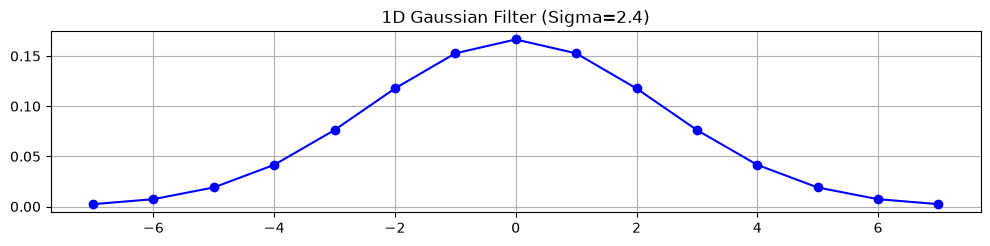

In [14]:
# Plot 1D
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(x, gauss, 'b-o')
plt.title(f'1D Gaussian Filter (Sigma={sigma})')
plt.grid(True)

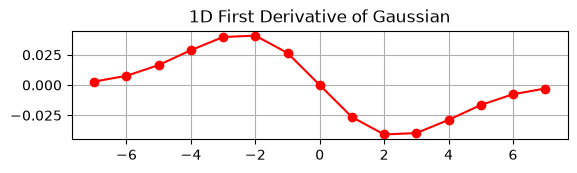

In [16]:
plt.subplot(3, 1, 2)
plt.plot(x, first_derivative_gauss, 'r-o')
plt.title('1D First Derivative of Gaussian')
plt.grid(True)


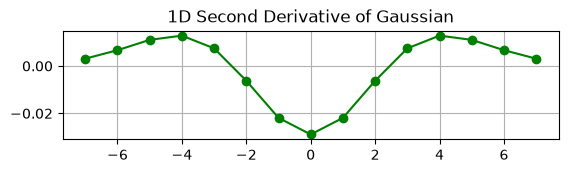

In [21]:
plt.subplot(3, 1, 3)
plt.plot(x, second_derivative_gauss, 'g-o')
plt.title('1D Second Derivative of Gaussian')
plt.grid(True)




In [29]:
# Apply the filters to the input image
from scipy.ndimage import convolve1d
# Smoothing
img_smoothed = convolve1d(input_image, gauss, axis=1)

# First Derivative (Edge detection)
img_edge_1st = convolve1d(input_image, first_derivative_gauss, axis=1)

# Second Derivative (Zero-crossing detection)
img_edge_2nd = convolve1d(input_image, second_derivative_gauss, axis=1)